# CPTS 440 — Chess Agent Demo

This notebook demonstrates our depth-limited minimax search engine with material evaluation.

**What you'll see:**
1. Engine overview, having it choose moves and reporting search statistics
2. Tactical puzzle solving (mate-in-1, winning material)
3. Depth comparison, how deeper search finds better moves at higher cost
4. A full AI-vs-AI game with move-by-move visualization

In [1]:
import chess
import chess.svg
from IPython.display import SVG, display, HTML

from src import engine
from src.engine import play_game

---
## 1. Engine Overview

Our agent uses **depth-limited minimax** search with a **material-based evaluation function**.

- **Search**: Explores the game tree to a fixed depth, alternating between maximizing (White) and minimizing (Black) players
- **Evaluation**: Scores positions in centipawns based on material balance (P=100, N=320, B=330, R=500, Q=900)
- **Move ordering**: Captures and checks are searched first to improve pruning in future iterations

Let's give the engine a position and see what it finds.

In [2]:
board = chess.Board()

result = engine.choose_move(board, depth=2)

print(f"Best move : {result.move}")
print(f"Eval score: {result.score:+.0f} centipawns")
print(f"Nodes     : {result.nodes:,}")
print(f"Depth     : {result.depth} plies")

Best move : g1f3
Eval score: +0 centipawns
Nodes     : 84
Depth     : 2 plies


In [3]:
# Show the board BEFORE and AFTER the engine's chosen move, side by side
before_svg = chess.svg.board(
    board, size=350,
    arrows=[chess.svg.Arrow(result.move.from_square, result.move.to_square, color="#cc220080")],
)

board_after = board.copy()
board_after.push(result.move)
after_svg = chess.svg.board(
    board_after, size=350,
    fill={result.move.to_square: "#88cc44"},
)

display(HTML(f"""
<div style='display:flex; gap:2em; align-items:center'>
  <div><h4>Before</h4>{before_svg}</div>
  <div style='font-size:2em'>→</div>
  <div><h4>After {result.move}</h4>{after_svg}</div>
</div>
"""))

---
## 2. Tactical Puzzles

Can the engine solve simple tactics? Let's test it on known positions.

In [4]:
def show_puzzle(title: str, fen: str, expected_uci: str, depth: int = 3) -> None:
    """Display a puzzle position, let the engine solve it, and show the result."""
    board = chess.Board(fen)
    result = engine.choose_move(board, depth=depth)

    found = result.move.uci() if result.move else "(none)"
    match = "✅" if found == expected_uci else "❌"

    board_after = board.copy()
    if result.move:
        board_after.push(result.move)

    before_svg = chess.svg.board(
        board, size=300,
        arrows=(
            [chess.svg.Arrow(result.move.from_square, result.move.to_square, color="#cc220080")]
            if result.move else []
        ),
    )
    after_svg = chess.svg.board(board_after, size=300)

    display(HTML(f"""
    <h3>{title} {match}</h3>
    <p>Engine chose <b>{found}</b> (expected <b>{expected_uci}</b>)
    — eval: {result.score:+.0f} cp, nodes: {result.nodes:,}, depth: {result.depth}</p>
    <div style='display:flex; gap:1.5em; align-items:center'>
      <div>{before_svg}</div>
      <div style='font-size:1.5em'>→</div>
      <div>{after_svg}</div>
    </div>
    """))

In [5]:
# Puzzle 1: White to move with mate in 1 by Qh5#
show_puzzle(
    title="Mate in 1",
    fen="rnbqkbnr/pppp1ppp/8/4p3/6P1/5P2/PPPPP2P/RNBQKBNR b KQkq - 0 2",
    expected_uci="d8h4",
    depth=3,
)

In [6]:
# Puzzle 2: White to move with win by capturing Black's hanging queen
show_puzzle(
    title="Win the queen",
    fen="r1bqkbnr/pppppppp/2n5/8/3NP3/8/PPP2PPP/RNBQKB1R w KQkq - 1 3",
    expected_uci="d4c6",
    depth=2,
)

In [7]:
# Puzzle 3: White to move with back-rank mate by Qe8# (rook guards, king trapped)
show_puzzle(
    title="Back-rank mate",
    fen="6k1/5ppp/8/8/8/8/1Q3PPP/6K1 w - - 0 1",
    expected_uci="b2b8",
    depth=3,
)

---
## 3. Depth Comparison

How does increasing search depth affect the engine's choice and the cost (nodes searched)?

We run the same position at depth 1, 2, and 3 and compare.

Position: r1bqkb1r/pppppppp/2n2n2/8/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3

Depth    Best Move    Score (cp)        Nodes
----------------------------------------------
1        b1c3         40++++++++++         29
2        b1c3         -90+++++++++        172
3        f1b5         85++++++++++      1,468


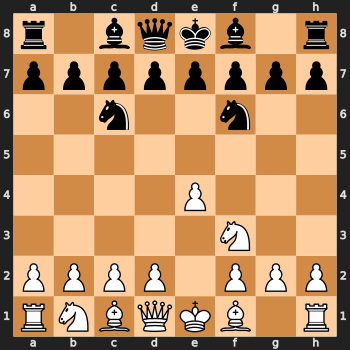

In [8]:
fen = "r1bqkb1r/pppppppp/2n2n2/8/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3"
board = chess.Board(fen)

print(f"Position: {fen}\n")
print(f"{'Depth':<8} {'Best Move':<12} {'Score (cp)':<12} {'Nodes':>10}")
print("-" * 46)

for d in range(1, 4):
    result = engine.choose_move(board, depth=d)
    move_str = result.move.uci() if result.move else "(none)"
    print(f"{d:<8} {move_str:<12} {result.score:+<12.0f} {result.nodes:>10,}")

SVG(chess.svg.board(board, size=350))

Notice how:
- **Node count grows exponentially** with depth (branching factor ~30–35 in the middlegame)
- **Deeper search can change the best move** as the engine sees further consequences
- This motivates alpha-beta pruning to search deeper within the same node budget

---
## 3b. Alpha-Beta vs. Plain Minimax

Here we compare the same position using:
- **Alpha-beta pruning enabled**
- **Plain minimax** with no pruning

Both searches use the same evaluation function, but alpha-beta should usually examine **far fewer nodes**. The chart below makes that efficiency difference easy to see.

Depth,Mode,Best move,Score,Nodes searched,Time
1,Alpha-Beta,b1c3,+40,29,0.86 ms
1,Minimax,b1c3,+40,29,0.77 ms
2,Alpha-Beta,b1c3,-90,172,5.84 ms
2,Minimax,b1c3,-90,696,16.01 ms
3,Alpha-Beta,f1b5,+85,"1,468",43.86 ms
3,Minimax,f1b5,+85,"20,493",494.60 ms
4,Alpha-Beta,b1c3,-90,"10,057",406.07 ms
4,Minimax,b1c3,-90,"525,335",12172.00 ms


Depth  Mode         Best Move     Score      Nodes    Time (ms)
------------------------------------------------------------------
1      Alpha-Beta   b1c3            +40         29         0.86
1      Minimax      b1c3            +40         29         0.77
2      Alpha-Beta   b1c3            -90        172         5.84
2      Minimax      b1c3            -90        696        16.01
3      Alpha-Beta   f1b5            +85      1,468        43.86
3      Minimax      f1b5            +85     20,493       494.60
4      Alpha-Beta   b1c3            -90     10,057       406.07
4      Minimax      b1c3            -90    525,335     12172.00


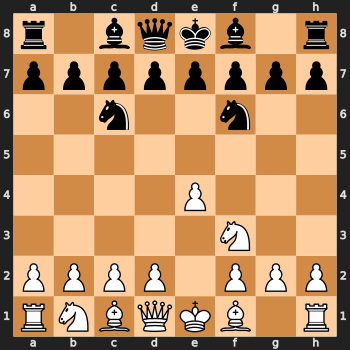

In [17]:
import time
from src.search import choose_move as search_choose_move

compare_fen = "r1bqkb1r/pppppppp/2n2n2/8/4P3/5N2/PPPP1PPP/RNBQKB1R w KQkq - 2 3"
compare_board = chess.Board(compare_fen)

rows = []
for d in range(1, 5):
    for label, use_ab, color in [
        ("Alpha-Beta", True, "#2a9d8f"),
        ("Minimax", False, "#e76f51"),
    ]:
        start = time.perf_counter()
        result = search_choose_move(compare_board.copy(), depth=d, use_alpha_beta=use_ab)
        elapsed_ms = (time.perf_counter() - start) * 1000
        rows.append({
            "depth": d,
            "mode": label,
            "move": result.move.uci() if result.move else "(none)",
            "score": result.score,
            "nodes": result.nodes,
            "time_ms": elapsed_ms,
            "color": color,
        })

max_nodes = max(row["nodes"] for row in rows)
max_time = max(row["time_ms"] for row in rows)

summary = []
for d in range(1, 5):
    mm = next(r for r in rows if r["depth"] == d and r["mode"] == "Minimax")
    ab = next(r for r in rows if r["depth"] == d and r["mode"] == "Alpha-Beta")
    saved = mm["nodes"] - ab["nodes"]
    saved_pct = (saved / mm["nodes"] * 100) if mm["nodes"] else 0
    summary.append((d, saved, saved_pct))

html_rows = []
for row in rows:
    node_width = max(6, int(220 * row["nodes"] / max_nodes))
    time_width = max(6, int(120 * row["time_ms"] / max_time)) if max_time else 6
    html_rows.append(f"""
    <tr>
      <td>{row['depth']}</td>
      <td><b>{row['mode']}</b></td>
      <td><code>{row['move']}</code></td>
      <td>{row['score']:+.0f}</td>
      <td>{row['nodes']:,}<div style='height:10px; width:{node_width}px; background:{row['color']}; border-radius:4px; margin-top:4px'></div></td>
      <td>{row['time_ms']:.2f} ms<div style='height:10px; width:{time_width}px; background:{row['color']}; border-radius:4px; margin-top:4px'></div></td>
    </tr>
    """)

summary_items = "".join(
    f"<li><b>Depth {d}</b>: alpha-beta searched {saved:,} fewer nodes ({saved_pct:.1f}% saved)</li>"
    for d, saved, saved_pct in summary
)

display(HTML(f"""
<h3>Alpha-Beta vs. Minimax</h3>
<p><b>Position:</b> <code>{compare_fen}</code></p>
<table style='border-collapse:collapse; min-width:760px'>
  <tr style='background:#f3f3f3'>
    <th style='padding:6px 10px; border:1px solid #ccc'>Depth</th>
    <th style='padding:6px 10px; border:1px solid #ccc'>Mode</th>
    <th style='padding:6px 10px; border:1px solid #ccc'>Best move</th>
    <th style='padding:6px 10px; border:1px solid #ccc'>Score</th>
    <th style='padding:6px 10px; border:1px solid #ccc'>Nodes searched</th>
    <th style='padding:6px 10px; border:1px solid #ccc'>Time</th>
  </tr>
  {''.join(html_rows)}
</table>
<ul>{summary_items}</ul>
"""))

print(f"{'Depth':<6} {'Mode':<12} {'Best Move':<10} {'Score':>8} {'Nodes':>10} {'Time (ms)':>12}")
print("-" * 66)
for row in rows:
    print(f"{row['depth']:<6} {row['mode']:<12} {row['move']:<10} {row['score']:>+8.0f} {row['nodes']:>10,} {row['time_ms']:>12.2f}")

SVG(chess.svg.board(compare_board, size=350))

---
## 4. AI vs. AI Game

Let's run a full game where the engine plays both sides, then visualize the result.

In [9]:
game = play_game(white_depth=2, black_depth=2, max_moves=80)

print(f"Game result : {game.result}")
print(f"Total plies : {len(game.plies)}")
print(f"Total nodes : {sum(p.nodes for p in game.plies):,}")

Game result : 1/2-1/2
Total plies : 37
Total nodes : 10,035


In [ ]:
# Per-ply metrics table: move, score, nodes, depth, time, and a simple eval bar
print(f"{'Ply':<5} {'Move':<8} {'Score':>7} {'Nodes':>8} {'Depth':>6} {'ms':>7}  {'Eval bar'}")
print("-" * 70)

for i, ply in enumerate(game.plies):
    bar_len = int(ply.score / 50)
    if bar_len >= 0:
        bar = " " * 20 + "█" * min(bar_len, 20)
    else:
        filled = min(abs(bar_len), 20)
        bar = " " * (20 - filled) + "█" * filled
    depth_str = str(ply.depth) if ply.depth > 0 else "-"
    ms_str = f"{ply.elapsed * 1000:.1f}"
    print(f"{i+1:<5} {ply.move_uci:<8} {ply.score:>+7.0f} {ply.nodes:>8,} {depth_str:>6} {ms_str:>7}  |{bar}|")

Ply    Move       Score (cp)    Nodes  Bar
------------------------------------------------------------
1      g1f3               +0       84  |                    |
2      g8f6              +50      110  |                    █|
3      b1c3               +0      112  |                    |
4      b8c6              +40       94  |                    |
5      e2e3              -20      271  |                    |
6      e7e6              +40      305  |                    |
7      f1c4              -20      364  |                    |
8      f8d6             +100      171  |                    ██|
9      h2h3              -30      313  |                    |
10     e8g8              +70      184  |                    █|
11     e1g1              -20      483  |                    |
12     f8e8              +95      139  |                    █|
13     d2d3               -5      465  |                    |
14     d8e7             +110      174  |                    ██|
15     c1d2          

In [ ]:
# GameRecord aggregate metrics
print("=== Game Summary ===")
print(f"Result         : {game.result}")
print(f"Plies played   : {len(game.plies)}")
print(f"Total time     : {game.total_time_ms:,.1f} ms")
print(f"Avg time/ply   : {game.avg_time_ms:,.1f} ms")
print(f"Avg nodes/ply  : {game.avg_nodes:,.1f}")
print(f"Peak nodes     : {game.peak_nodes:,}")
print(f"Avg depth      : {game.avg_depth:.1f} plies")

In [11]:
# Visualize key moments: first move, a midgame position, and the final position
snapshots = []
indices = [0, len(game.plies) // 2, len(game.plies) - 1]

for idx in indices:
    ply = game.plies[idx]
    b = chess.Board(ply.fen_before)
    move = chess.Move.from_uci(ply.move_uci)
    svg = chess.svg.board(
        b, size=280,
        arrows=[chess.svg.Arrow(move.from_square, move.to_square, color="#cc220080")],
    )
    snapshots.append(f"""
    <div style='text-align:center'>
      <h4>Ply {idx + 1}: {ply.move_uci}</h4>
      <p>Eval: {ply.score:+.0f} cp</p>
      {svg}
    </div>
    """)

display(HTML(f"<div style='display:flex; gap:1em; flex-wrap:wrap'>{''.join(snapshots)}</div>"))

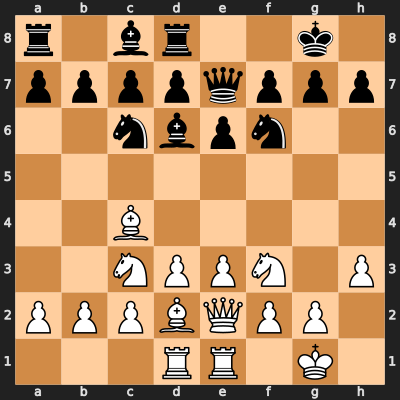

In [12]:
# Show the final board position
final_board = chess.Board(game.final_fen)
display(HTML(f"<h3>Final Position — Result: {game.result}</h3>"))
SVG(chess.svg.board(final_board, size=400))

---
### Interactive HTML Replay

Export the game above to a standalone HTML file with play/pause controls.
Open `game_replay.html` in any browser.

> Use the command `explorer.exe game_replay.html` in the terminal.

In [13]:
from src.viz import export_game_html

out = export_game_html(game, "game_replay.html")
print(f"Replay saved to: {out}")

Replay saved to: C:\Users\Dillon\School\Artificial Intelligence\CPTS440-Chess-Game-Playing-Agent\game_replay.html


---
## Section 5 — Positional Evaluation (PST Comparison)

Piece-square tables (PSTs) assign a positional bonus to each piece based on which square it occupies.
A centralized knight gets up to +20 cp more than a rim knight.
A castled king scores +30 cp vs 0 cp for a king stuck in the centre.

This section shows:
- How the same material counts differently with vs without PSTs
- Which moves the engine **prefers** because of positional bonuses
- A visual heatmap of the PST values for each piece type

In [14]:
from src import eval as ev

# Positions that highlight the PST effect
positions = [
    ("Knight center (e4) vs rim (a1) — material equal",
     "4k3/8/8/8/4N3/8/7P/4K3 w - - 0 1",
     "4k3/8/8/8/8/8/7P/N3K3 w - - 0 1"),
    ("Pawn advanced (e4) vs retreated (e2) — material equal",
     "4k3/8/8/8/4P3/8/8/4K3 w - - 0 1",
     "4k3/8/8/8/8/8/4P3/4K3 w - - 0 1"),
    ("King castled (g1) vs exposed (e1) — material equal",
     "4k3/8/8/8/8/8/7P/6K1 w - - 0 1",
     "4k3/8/8/8/8/8/7P/4K3 w - - 0 1"),
]

header = f"{'Scenario':<45} {'Pos A (no PST)':>14} {'Pos A (+PST)':>14} {'Pos B (no PST)':>14} {'Pos B (+PST)':>14} {'PST delta':>10}"
print(header)
print("-" * len(header))
for label, fen_a, fen_b in positions:
    ba, bb = chess.Board(fen_a), chess.Board(fen_b)
    a_raw = ev.evaluate(ba, use_pst=False)
    a_pst = ev.evaluate(ba, use_pst=True)
    b_raw = ev.evaluate(bb, use_pst=False)
    b_pst = ev.evaluate(bb, use_pst=True)
    delta = a_pst - b_pst
    print(f"{label:<45} {a_raw:>+14.0f} {a_pst:>+14.0f} {b_raw:>+14.0f} {b_pst:>+14.0f} {delta:>+10.0f}")

Scenario                                      Pos A (no PST)   Pos A (+PST) Pos B (no PST)   Pos B (+PST)  PST delta
--------------------------------------------------------------------------------------------------------------------
Knight center (e4) vs rim (a1) — material equal           +420           +445           +420           +375        +70
Pawn advanced (e4) vs retreated (e2) — material equal           +100           +120           +100            +80        +40
King castled (g1) vs exposed (e1) — material equal           +100           +135           +100           +105        +30


Mode          Best move    Score    Nodes
------------------------------------------
With PST           g1f3     +0.0       84
No PST             g1h3     +0.0       60

  PSTs changed the engine's choice: g1h3 → g1f3


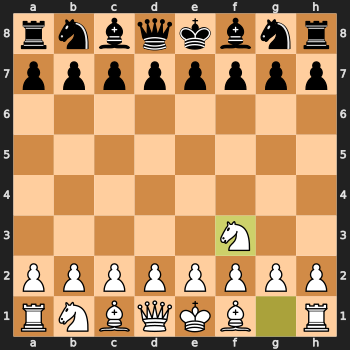

In [15]:
from src.search import choose_move

# Does PST change the first move the engine picks from the opening position?
# We compare choose_move() (which uses PSTs via eval.evaluate) with a patched
# call that forces use_pst=False by temporarily runtime patch to evaluate.

import functools

def _choose_move_no_pst(board, *, depth=2):
    """Run choose_move with PSTs disabled by patching evaluate temporarily."""
    original = ev.evaluate
    ev.evaluate = functools.partial(original, use_pst=False)
    try:
        result = choose_move(board, depth=depth)
    finally:
        ev.evaluate = original
    return result

board = chess.Board()
res_pst  = choose_move(board, depth=2)
res_raw  = _choose_move_no_pst(board, depth=2)

print(f"{'Mode':<12} {'Best move':>10} {'Score':>8} {'Nodes':>8}")
print("-" * 42)
print(f"{'With PST':<12} {str(res_pst.move):>10} {res_pst.score:>+8.1f} {res_pst.nodes:>8}")
print(f"{'No PST':<12} {str(res_raw.move):>10} {res_raw.score:>+8.1f} {res_raw.nodes:>8}")

if res_pst.move != res_raw.move:
    print(f"\n  PSTs changed the engine's choice: {res_raw.move} → {res_pst.move}")
else:
    print(f"\n  Both modes agree on best move: {res_pst.move}")

# Show the board after the PST-preferred move
board_after = chess.Board()
board_after.push(res_pst.move)
display(HTML("<b>Position after PST-preferred first move:</b>"))
display(SVG(chess.svg.board(board_after, size=350, lastmove=res_pst.move)))

In [16]:
from src.eval import PST_PAWN, PST_KNIGHT, PST_BISHOP, PST_ROOK, PST_QUEEN, PST_KING_MIDDLEGAME

# ASCII heat-map helper
def _heatmap(table: list[int], title: str) -> None:
    """Print a coloured ASCII grid (rank 8 at top, file a at left)."""
    lo, hi = min(table), max(table)
    span = max(hi - lo, 1)
    COLS = ["\033[38;5;21m", "\033[38;5;39m", "\033[38;5;82m",
            "\033[38;5;226m", "\033[38;5;208m", "\033[38;5;196m"]
    RESET = "\033[0m"
    print(f"\n  {title}")
    print("   a    b    c    d    e    f    g    h")
    for rank in range(7, -1, -1):          # rank 8 → rank 1
        row = ""
        for file in range(8):              # file a → h
            sq = rank * 8 + file
            val = table[sq]
            idx = int((val - lo) / span * (len(COLS) - 1))
            row += f"{COLS[idx]}{val:+4d}{RESET} "
        print(f"{rank+1}  {row}")

tables = [
    (PST_PAWN,            "PAWN"),
    (PST_KNIGHT,          "KNIGHT"),
    (PST_BISHOP,          "BISHOP"),
    (PST_ROOK,            "ROOK"),
    (PST_QUEEN,           "QUEEN"),
    (PST_KING_MIDDLEGAME, "KING (middlegame)"),
]
for tbl, name in tables:
    _heatmap(tbl, name)


  PAWN
   a    b    c    d    e    f    g    h
8    +0   +0   +0   +0   +0   +0   +0   +0 
7   +50  +50  +50  +50  +50  +50  +50  +50 
6   +10  +10  +20  +30  +30  +20  +10  +10 
5    +5   +5  +10  +25  +25  +10   +5   +5 
4    +0   +0   +0  +20  +20   +0   +0   +0 
3    +5   -5  -10   +0   +0  -10   -5   +5 
2    +5  +10  +10  -20  -20  +10  +10   +5 
1    +0   +0   +0   +0   +0   +0   +0   +0 

  KNIGHT
   a    b    c    d    e    f    g    h
8   -50  -40  -30  -30  -30  -30  -40  -50 
7   -40  -20   +0   +0   +0   +0  -20  -40 
6   -30   +0  +10  +15  +15  +10   +0  -30 
5   -30   +5  +15  +20  +20  +15   +5  -30 
4   -30   +0  +15  +20  +20  +15   +0  -30 
3   -30   +5  +10  +15  +15  +10   +5  -30 
2   -40  -20   +0   +5   +5   +0  -20  -40 
1   -50  -40  -30  -30  -30  -30  -40  -50 

  BISHOP
   a    b    c    d    e    f    g    h
8   -20  -10  -10  -10  -10  -10  -10  -20 
7   -10   +0   +0   +0   +0   +0   +0  -10 
6   -10   +0   +5  +10  +10   +5   +0  -10 
5   -10   +5   +

## Structured AI-vs-AI Experiments

This section runs the matchup matrix used for the final comparison report. The notebook keeps the code path close to the repository runner so the exported JSON, CSV, and HTML artifacts stay reproducible.


In [ ]:
from pathlib import Path

from src.experiments import build_default_matchups, run_matchups, write_metrics_bundle

# Full final-report run: 100 games per matchup.
# For quick smoke runs during development, reduce games to 4 or 10.
matchups = build_default_matchups(games=100)
summaries = run_matchups(matchups)
paths = write_metrics_bundle(summaries, Path("artifacts/experiments"))
paths


## Human vs AI

Play interactively against the engine.  
Enter moves in **UCI notation** (e.g. `e2e4`, `g1f3`, `a7a8q` for promotion).  
Type `resign` to end the game early.

The board is printed after every move, and the full `GameRecord` is returned so you can export it to HTML or inspect individual plies afterwards.

In [ ]:
from src.engine import play_human_vs_ai
from src.viz import export_game_html

HUMAN_COLOR = "white"   # "white" or "black"
AI_DEPTH    = 2         # search depth for the AI (higher = stronger but slower)

import chess

human_game = play_human_vs_ai(
    human_color=chess.WHITE if HUMAN_COLOR == "white" else chess.BLACK,
    ai_depth=AI_DEPTH,
)

print(f"\nGame over — result: {human_game.result}")
print(f"Plies played: {len(human_game.plies)}")

# Export replay so you can step through the game in a browser.
replay_path = export_game_html(human_game, "artifacts/human_vs_ai_replay.html")
print(f"Replay saved to: {replay_path}")